# 1. Import modules

First, I will import the necessary modules for this project: 
1. **Numpy:** for numerical computing,
2. **Pandas:** handles data in tables/dataframes,
3. **Regssion_coefs:** calculates regression coefficients, 
3. **Matplotlib and seaborn:** creates plots and graphs. 

In [2]:
# Importing numpy and pandas for numerical operations and data manipulation
import numpy as np
import pandas as pd 

# Importing our custom function that estimates regression coefficients,
# which we will use later to extract the GDP trend from the data
from get_regression_coefs_general import get_regression_coefs # import our function to get GDP trend

# Importing plotting libraries. We use seaborn on top of matplotlib
# to produce cleaner, more visually appealing figures
import matplotlib.pyplot as plt
import seaborn as sns # for nicer plots
sns.set_theme('talk', style = 'white')

# 2. Loading and cleaning the dataset

The Penn World Table is the standard dataset for macroeconomic analysis, and includes variables such as Real GDP at national prices, Capital Stock at national prices, Employment, and Human Capital Index, covering 185 countries between 1950 and 2023. It uses 2021 as the base year for constant prices.

We first load the dataset and browse its key features, such as column names and the first few rows.

In [3]:
# 2.1) Load dataset

data = pd.read_excel('pwt110_download_2025_11_24.xlsx', sheet_name='Data')

# Quick overview of the dataset's dimensions, variables, and first few rows
print(f"Shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
print(data.head())

Shape: (13690, 51)
Columns: ['countrycode', 'country', 'currency_unit', 'year', 'rgdpe', 'rgdpo', 'pop', 'emp', 'avh', 'hc', 'ccon', 'cda', 'cgdpe', 'cgdpo', 'cn', 'ck', 'ctfp', 'cwtfp', 'rgdpna', 'rconna', 'rdana', 'rnna', 'rkna', 'rtfpna', 'rwtfpna', 'labsh', 'irr', 'delta', 'xr', 'pl_con', 'pl_da', 'pl_gdpo', 'i_cig', 'i_xm', 'i_xr', 'i_outlier', 'i_irr', 'cor_exp', 'csh_c', 'csh_i', 'csh_g', 'csh_x', 'csh_m', 'csh_r', 'pl_c', 'pl_i', 'pl_g', 'pl_x', 'pl_m', 'pl_n', 'pl_k']
  countrycode country   currency_unit  year  rgdpe  rgdpo  pop  emp  avh  hc  \
0         ABW   Aruba  Aruban Guilder  1950    NaN    NaN  NaN  NaN  NaN NaN   
1         ABW   Aruba  Aruban Guilder  1951    NaN    NaN  NaN  NaN  NaN NaN   
2         ABW   Aruba  Aruban Guilder  1952    NaN    NaN  NaN  NaN  NaN NaN   
3         ABW   Aruba  Aruban Guilder  1953    NaN    NaN  NaN  NaN  NaN NaN   
4         ABW   Aruba  Aruban Guilder  1954    NaN    NaN  NaN  NaN  NaN NaN   

   ...  csh_x  csh_m  csh_r  pl_c  pl

`Shape(13690, 51)` tells us that we have 13690 rows (for all 185 countries), and 51 columns (variables). We will analyse **Sri Lanka's long term trends**, so we will clean the data to keep only the data relevant for our analysis. 

In [4]:
# 2.2) Clean data

# Keep only the variables we need and compute per capita real GDP (rgdpe / population)
data = data.loc[:, ("country", "year", "rgdpe", "pop")]
data["rgdpe_pc"] = data["rgdpe"] / data["pop"]

# Filter for Sri Lanka only, keeping year, total GDP, and GDP per capita
data = data.loc[data["country"] == "Sri Lanka", ("year", "rgdpe", "rgdpe_pc")]

# Reset index after filtering so rows are numbered from 0 again
data = data.reset_index(drop=True)

# Define the time period for our analysis (1950–2023)
ymax = 2023
ymin = 1950

# Extract GDP per capita for 1950–2023 and take its log for trend analysis
Y_pc = data.loc[np.logical_and(data["year"] <= ymax, data["year"] >= ymin), "rgdpe_pc"]
y_pc = np.log(Y_pc)

# Same for total GDP: log transformation allows us to interpret trends as growth rates
Y_gdp = data.loc[np.logical_and(data["year"] <= ymax, data["year"] >= ymin), "rgdpe"]
y_gdp = np.log(Y_gdp)

# Drop pre-1950 observations since they fall outside our analysis period
data = data[data["year"] >= ymin]

# T = number of years in the regression sample; T_all = total years available from 1950 onward
T = len(Y_pc)
T_all = data["year"].max() - (ymin - 1)

In [5]:
data # Browse the filtered data for Sri Lanka (1950-2023) 

,year,rgdpe,rgdpe_pc
0,1950,25357.488281,3456.990971
1,1951,27267.125000,3610.934647
2,1952,24134.570312,3102.942043
3,1953,25326.912109,3160.501812
4,1954,28594.119141,3467.465989
...,...,...,...
69,2019,322498.687500,14390.483889
70,2020,289517.468750,12832.193306
71,2021,309878.718750,13650.821174
72,2022,287845.812500,12605.485163


We've filtered the initial data to only keep Sri Lanka from 1950 to 2023, and selected total GDP and GDP per capita! The  dataset contains 74 rows, consistent with the number of years in this time period.


# 3. Coding and analysis 

## A. Trend Calculation

The project instructs us to compute four different trend specifications for: 
1. **Additive Linear**, 
2. **Additive Quadratic**, 
3. **Exponential Linear**, 
4. **Exponential Quadratic**. 

To run a linear regression, we can simply compute `get_regression_coefs(y, x1, x1)`. Once we code for 3.1 Additive Linear Model, we can simply reuse the code to fit the other cases.  

### 3.1 Additive Linear Model

First, we will compute the Additive Linear mode for both Total GDP and GDP per capita.

In [6]:
# Constructing regressors: x1 is a constant (vector of ones) and x2 is a linear time trend (1, 2, ..., T)
# The dependent variable is log GDP in levels
x1 = np.empty(T)
x2 = np.empty(T)

for t in range(T):
    x1[t] = 1.
    x2[t] = t + 1  # +1 because Python indexes from 0 but our time trend starts at 1

# Estimate the linear trend coefficients (intercept a, slope b) for total GDP
a_add_lin_gdp, b_add_lin_gdp = get_regression_coefs(Y_gdp, x1, x2)

# Same regression but for GDP per capita
a_add_lin_pc, b_add_lin_pc = get_regression_coefs(Y_pc, x1, x2)

Now that we have the coefficients, we can evaluate the trend for the entire time series. Also, we will convert the dependent variable into logs, because growth rates are easier to interpret with logs. It is also easier to compare GDP levels across the time period. 

In [7]:
# Predictions for Total GDP 
# Generate fitted values (Yhat) from the linear trend: Yhat = a + b*(t+1) for each year
Yhat_add_lin_gdp = np.empty(T)
for t in range(T):
    Yhat_add_lin_gdp[t] = a_add_lin_gdp + b_add_lin_gdp * (t + 1)

# Convert predicted GDP levels to logs so we can plot them alongside the log GDP series
yhat_add_lin_gdp = np.log(Yhat_add_lin_gdp)

# Repeat for GDP per capita 
Yhat_add_lin_pc = np.empty(T)
for t in range(T):
    Yhat_add_lin_pc[t] = a_add_lin_pc + b_add_lin_pc * (t + 1)

# Convert to log-units for consistency with our log GDP per capita series
yhat_add_lin_pc = np.log(Yhat_add_lin_pc)

/var/folders/3l/x_n29jbd5dv5hq7x97zwtkw40000gn/T/ipykernel_76288/2323778247.py:8: RuntimeWarning: invalid value encountered in log
  yhat_add_lin_gdp = np.log(Yhat_add_lin_gdp)


Finally, we plot the two visualisations for Additive Linear side by side. The left plots Per Capita trend, while the right plots ln(GDP) trend. 

The blue line represents the datapoints from our dataframe, and the orange line plots the fitted linear trend over the years. 

We add vertical lines at our sub-period boundaries, ie. 1956, 1977, and 2009. More of this can be read in our essay. 

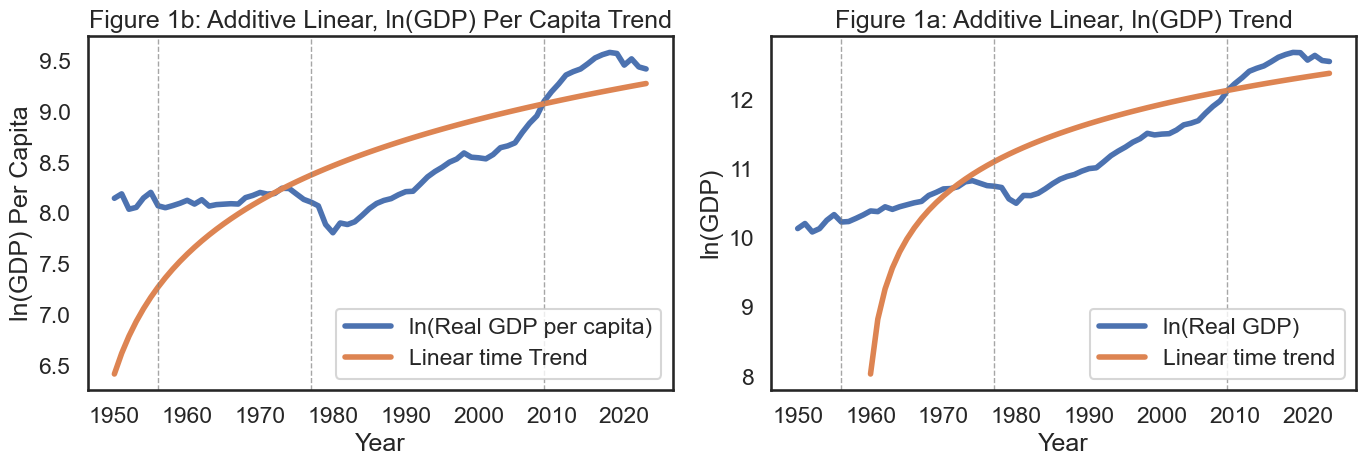

In [8]:
# Plotting actual log GDP alongside the additive linear trend to visually assess fit
lw = 4  # Thicker lines for readability
plt.figure(figsize=(14, 5))

# Panel 1b: Log GDP per capita vs its linear trend
plt.subplot(1, 2, 1)
plt.plot(data['year'], np.log(data['rgdpe_pc']), linewidth=lw, label='ln(Real GDP per capita)')
plt.plot(data['year'], yhat_add_lin_pc, linewidth=lw, label='Linear time Trend')
plt.xlabel("Year")
plt.ylabel("ln(GDP) Per Capita")
plt.title("Figure 1b: Additive Linear, ln(GDP) Per Capita Trend")
plt.xticks(range(1950, 2030, 10))

# Vertical lines at sub-period boundaries
for year in [1956, 1977, 2009]:
    plt.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.legend()

# Panel 1a: Log total GDP vs its linear trend
plt.subplot(1, 2, 2)
plt.plot(data['year'], np.log(data['rgdpe']), linewidth=lw, label='ln(Real GDP)')
plt.plot(data['year'], yhat_add_lin_gdp, linewidth=lw, label='Linear time trend')
plt.xlabel("Year")
plt.ylabel("ln(GDP)")
plt.title("Figure 1a: Additive Linear, ln(GDP) Trend")
plt.xticks(range(1950, 2030, 10))

# Vertical lines at sub-period boundaries
for year in [1956, 1977, 2009]:
    plt.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.legend()

# Prevent subplot labels from overlapping
plt.tight_layout()
plt.show()

### 3.2 Additive Quadratic Model

Now that we've coded for 3.1 Additive Linear model, we will simply update our code from above to fit the "quadratic modelling".

In [9]:
# 3.2) Additive Quadratic Model for both total GDP and GDP Per Capita
# We add a quadratic term (t²) alongside the linear term to capture curvature in the trend

x1 = np.empty(T)  # Constant term (vector of ones)
x2 = np.empty((T, 2))  # 2D array: column 0 for linear trend, column 1 for quadratic trend

for t in range(T):
    x1[t] = 1.
    x2[t, 0] = t + 1           # Linear time trend starting at 1
    x2[t, 1] = (t + 1)**2      # Quadratic term to allow the trend to accelerate or decelerate

In [10]:
# Same structure as 3.1 but now with three coefficients: intercept (a), linear (b1), and quadratic (b2)

# Total GDP 
# Estimate coefficients for the quadratic trend: log(GDP) = a + b1*t + b2*t²
a_add_quad_gdp, b_add_quad_lin_gdp, b_add_quad_sq_gdp = get_regression_coefs(y_gdp, x1, x2[:, 0], x2[:, 1])

# Generate fitted values using the quadratic trend equation
yhat_add_quad_gdp = np.empty(T)
for t in range(T):
    yhat_add_quad_gdp[t] = a_add_quad_gdp + b_add_quad_lin_gdp * (t + 1) + b_add_quad_sq_gdp * ((t + 1)**2)

# GDP per capita
# Same quadratic regression applied to log GDP per capita
a_add_quad_pc, b_add_quad_lin_pc, b_add_quad_sq_pc = get_regression_coefs(y_pc, x1, x2[:, 0], x2[:, 1])

# Generate fitted values for the per capita quadratic trend
yhat_add_quad_pc = np.empty(T)
for t in range(T):
    yhat_add_quad_pc[t] = a_add_quad_pc + b_add_quad_lin_pc * (t + 1) + b_add_quad_sq_pc * ((t + 1)**2)

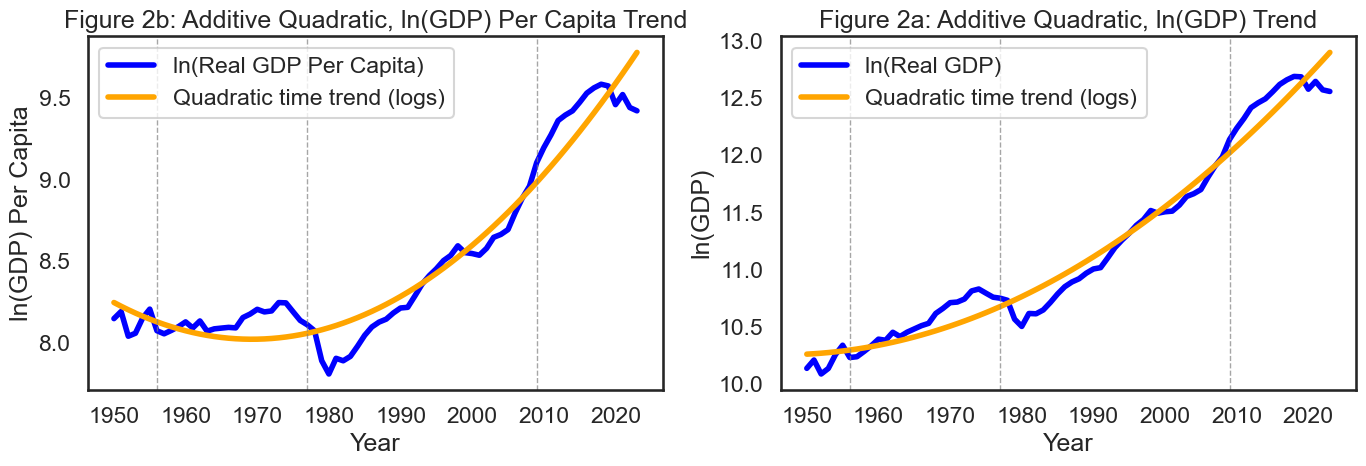

In [11]:
# Plotting actual log GDP alongside the additive quadratic trend to see if curvature improves fit
plt.figure(figsize=(14, 5))

# Panel 2b: Log GDP per capita vs its quadratic trend
plt.subplot(1, 2, 1)
plt.plot(data['year'], np.log(data['rgdpe_pc']), linewidth=lw, color='blue', label='ln(Real GDP Per Capita)')
plt.plot(data['year'], yhat_add_quad_pc, linewidth=lw, color='orange', label='Quadratic time trend (logs)')
plt.xlabel("Year")
plt.ylabel("ln(GDP) Per Capita")
plt.title("Figure 2b: Additive Quadratic, ln(GDP) Per Capita Trend")
plt.xticks(range(1950, 2030, 10))

# Vertical lines at sub-period boundaries
for year in [1956, 1977, 2009]:
    plt.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.legend()

# Panel 2a: Log total GDP vs its quadratic trend
plt.subplot(1, 2, 2)
plt.plot(data['year'], np.log(data['rgdpe']), linewidth=lw, color='blue', label='ln(Real GDP)')
plt.plot(data['year'], yhat_add_quad_gdp, linewidth=lw, color='orange', label='Quadratic time trend (logs)')
plt.xlabel("Year")
plt.ylabel("ln(GDP)")
plt.title("Figure 2a: Additive Quadratic, ln(GDP) Trend")
plt.xticks(range(1950, 2030, 10))

# Vertical lines at sub-period boundaries
for year in [1956, 1977, 2009]:
    plt.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.legend()

plt.tight_layout()
plt.show()

We can also print the linear and quadratic coefficients to check its coefficient and that the trend is upward-curving.

In [12]:
# Print the linear and quadratic slope coefficients to verify the trend direction and curvature
print(f"Linear coefficient: {b_add_quad_lin_gdp}")
print(f"Quadratic coefficient: {b_add_quad_sq_gdp}")

Linear coefficient: 0.0023488384912740932
Quadratic coefficient: 0.0004494488555070858


### 3.3 Linear Exponential Model 

Again, we can update our code from 3.1 to fit the Linear expoential model. 

In [13]:
# Constructing regressors for the multiplicative exponential trend model
x1 = np.empty(T)  # Constant term (vector of ones)
x2 = np.empty(T)

for t in range(T):
    x1[t] = 1.
    scaled_t = (t + 1) / 100  # Scale time down to avoid numerical overflow when exponentiating
    x2[t] = np.exp(scaled_t)  # Exponential regressor to capture multiplicative growth patterns

In [14]:
# Total GDP 
# Estimate coefficients for the exponential trend: GDP = a + b*exp(t/100)
a_exp_lin_gdp, b_exp_lin_gdp = get_regression_coefs(Y_gdp, x1, x2)

# Generate fitted values in levels, then convert to logs for plotting
Yhat_exp_lin_gdp = np.empty(T)
for t in range(T):
    scaled_t = (t + 1) / 100
    Yhat_exp_lin_gdp[t] = a_exp_lin_gdp + b_exp_lin_gdp * np.exp(scaled_t)
yhat_exp_lin_gdp = np.log(Yhat_exp_lin_gdp)

# GDP per capita 
# Same exponential trend regression applied to GDP per capita
a_exp_lin_pc, b_exp_lin_pc = get_regression_coefs(Y_pc, x1, x2)

Yhat_exp_lin_pc = np.empty(T)
for t in range(T):
    scaled_t = (t + 1) / 100
    Yhat_exp_lin_pc[t] = a_exp_lin_pc + b_exp_lin_pc * np.exp(scaled_t)
yhat_exp_lin_pc = np.log(Yhat_exp_lin_pc)

/var/folders/3l/x_n29jbd5dv5hq7x97zwtkw40000gn/T/ipykernel_76288/4270680547.py:10: RuntimeWarning: invalid value encountered in log
  yhat_exp_lin_gdp = np.log(Yhat_exp_lin_gdp)


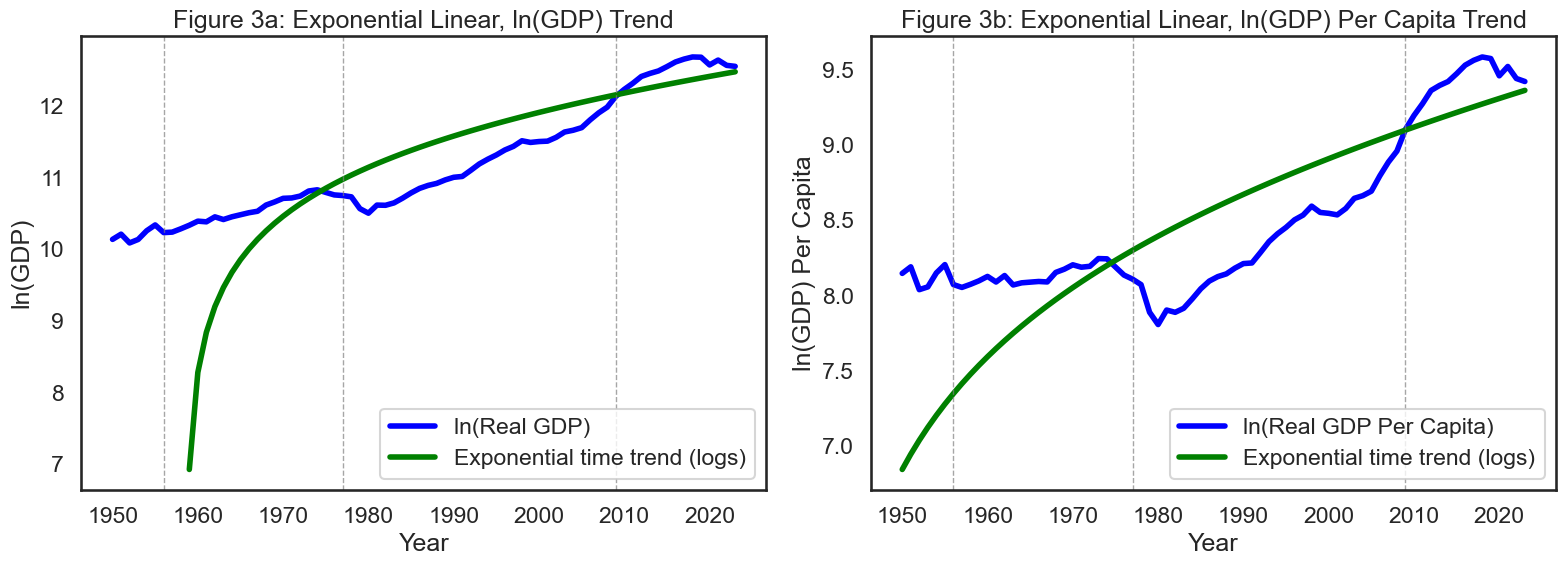

In [15]:
lw = 4

# Plotting actual log GDP against the exponential trend to assess how well exponential growth fits
plt.figure(figsize=(16, 6))

# Panel 3a: Log total GDP vs its exponential trend
plt.subplot(1, 2, 1)
plt.plot(data['year'], np.log(data['rgdpe']), linewidth=lw, color='blue', label='ln(Real GDP)')
plt.plot(data['year'], yhat_exp_lin_gdp, linewidth=lw, color='green', label='Exponential time trend (logs)')
plt.xlabel("Year")
plt.ylabel("ln(GDP)")
plt.title("Figure 3a: Exponential Linear, ln(GDP) Trend")
plt.xticks(range(1950, 2030, 10))

for year in [1956, 1977, 2009]:
    plt.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.legend()

# Panel 3b: Log GDP per capita vs its exponential trend
plt.subplot(1, 2, 2)
plt.plot(data['year'], np.log(data['rgdpe_pc']), linewidth=lw, color='blue', label='ln(Real GDP Per Capita)')
plt.plot(data['year'], yhat_exp_lin_pc, linewidth=lw, color='green', label='Exponential time trend (logs)')
plt.xlabel("Year")
plt.ylabel("ln(GDP) Per Capita")
plt.title("Figure 3b: Exponential Linear, ln(GDP) Per Capita Trend")
plt.xticks(range(1950, 2030, 10))

for year in [1956, 1977, 2009]:
    plt.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.legend()

plt.tight_layout()
plt.show()

### 3.4 Exponential Quadratic Model

Finally, repeat the same for 3.4 and update the 3.1 code to fit the Exponential Quadratic Model.  

In [16]:
# Constructing regressors for the multiplicative quadratic (exponential-quadratic) model
# We use exp(t/100) and t/100·exp(t/100) to capture both exponential growth and its acceleration

x1 = np.empty(T)  # Constant term (vector of ones)
x2 = np.empty((T, 2))  # 2D array: column 0 for exp term, column 1 for interaction term

for t in range(T):
    x1[t] = 1.
    scaled_t = (t + 1) / 100  # Scale time to avoid numerical overflow in the exponential
    x2[t, 0] = np.exp(scaled_t)        # Pure exponential term
    x2[t, 1] = scaled_t * np.exp(scaled_t)  # Interaction term allowing the exponential rate to vary

In [17]:
# Total GDP 
# Estimate coefficients: GDP = a + b1*exp(t/100) + b2*(t/100)*exp(t/100)
a_exp_quad_gdp, b_exp_quad_exp_gdp, b_exp_quad_texp_gdp = get_regression_coefs(Y_gdp, x1, x2[:, 0], x2[:, 1])

# Generate fitted values in levels using the exponential-quadratic equation, then log for plotting
Yhat_exp_quad_gdp = np.empty(T)
for t in range(T):
    scaled_t = (t + 1) / 100
    Yhat_exp_quad_gdp[t] = a_exp_quad_gdp + b_exp_quad_exp_gdp * np.exp(scaled_t) + b_exp_quad_texp_gdp * scaled_t * np.exp(scaled_t)
yhat_exp_quad_gdp = np.log(Yhat_exp_quad_gdp)

# GDP per capita 
# Same exponential-quadratic regression applied to GDP per capita
a_exp_quad_pc, b_exp_quad_exp_pc, b_exp_quad_texp_pc = get_regression_coefs(Y_pc, x1, x2[:, 0], x2[:, 1])

Yhat_exp_quad_pc = np.empty(T)
for t in range(T):
    scaled_t = (t + 1) / 100
    Yhat_exp_quad_pc[t] = a_exp_quad_pc + b_exp_quad_exp_pc * np.exp(scaled_t) + b_exp_quad_texp_pc * scaled_t * np.exp(scaled_t)
yhat_exp_quad_pc = np.log(Yhat_exp_quad_pc)

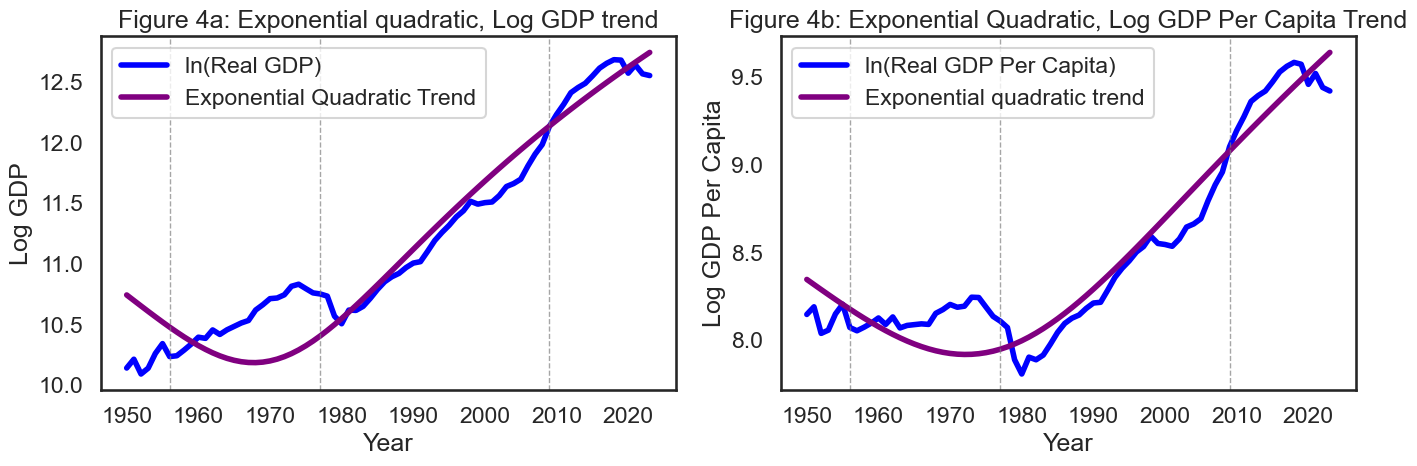

In [18]:
# Plotting actual log GDP against the exponential-quadratic trend to see if the interaction term improves fit
plt.figure(figsize=(14, 5))

# Panel 4a: Log total GDP vs its exponential-quadratic trend
plt.subplot(1, 2, 1)
plt.plot(data['year'], np.log(data['rgdpe']), linewidth=lw, color='blue', label='ln(Real GDP)')
plt.plot(data['year'], yhat_exp_quad_gdp, linewidth=lw, color='purple', label='Exponential Quadratic Trend')
plt.xlabel("Year")
plt.ylabel("Log GDP")
plt.title("Figure 4a: Exponential quadratic, Log GDP trend")
plt.xticks(range(1950, 2030, 10))

for year in [1956, 1977, 2009]:
    plt.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.legend()

# Panel 4b: Log GDP per capita vs its exponential-quadratic trend
plt.subplot(1, 2, 2)
plt.plot(data['year'], np.log(data['rgdpe_pc']), linewidth=lw, color='blue', label='ln(Real GDP Per Capita)')
plt.plot(data['year'], yhat_exp_quad_pc, linewidth=lw, color='purple', label='Exponential quadratic trend')
plt.xlabel("Year")
plt.ylabel("Log GDP Per Capita")
plt.title("Figure 4b: Exponential Quadratic, Log GDP Per Capita Trend")
plt.xticks(range(1950, 2030, 10))

for year in [1956, 1977, 2009]:
    plt.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.legend()

plt.tight_layout()
plt.show()

We are done with Part A, as we have finished plotting the four models and considered which one fits best for our Sri Lankan data. 

Visually, the quadratic models (3.2 and 3.4) fit better than the linear ones (3.1 and 3.3). However, we were surprised to see an upward U-shape in our visualisations.

# B. Extract TFP Measure

## Production Function

We use the Cobb-Douglas production function with human capital:

$$
Y = K^{\alpha}(AhL)^{1-\alpha}, \quad 0 < \alpha < 1
$$

where $Y$ is real GDP, $K$ is the capital stock, $L$ is employment, $h$ is the human capital index per worker, $A$ is Total Factor Productivity (TFP), and $\alpha = 0.3$ is the capital share of output. This is the one learned during our lectures. 

## Solving for TFP

Rearranging the production function to isolate $A$:

$$
A = \frac{Y^{1/(1-\alpha)}}{K^{\alpha/(1-\alpha)} \cdot h \cdot L}
$$

Taking logs, this becomes:

$$
\ln(A) = \frac{1}{1-\alpha}\ln(Y) - \frac{\alpha}{1-\alpha}\ln(K) - \ln(h) - \ln(L)
$$

Substituting $\alpha = 0.3$:

$$
\ln(A) \approx 1.429\ln(Y) - 0.429\ln(K) - \ln(h) - \ln(L)
$$

Again, this comes from the lecture slides. More on our choice of alpha = 0.3 can be read in the essay, but it follows the standard convention. We also peform a robustness check below. 

## Data Variables

All data is sourced from the Penn World Table (PWT 11.0) for Sri Lanka (1950–2023). We use `rgdpna` for real GDP ($Y$), `rnna` for the capital stock ($K$), `emp` for employment ($L$), and `hc` for the human capital index ($h$), all measured at constant 2017 national prices where applicable.

We now move to Part B: growth accounting. Using our Cobb-Douglas production function from above, we extract TFP from the data and decompose Sri Lanka's GDP growth into contributions from capital, labour, human capital, and productivity. Here, we compute and model one vrersion WITHOUT human capital, and one WITH human cpaital to see how they differ.

In [19]:
# Reload the PWT dataset to extract variables needed for TFP calculation
data_tfp = pd.read_excel('pwt110_download_2025_11_24.xlsx', sheet_name='Data')

# Keep only the columns relevant to growth accounting: output (rgdpna), capital (rnna), employment (emp), and human capital (hc)
data_tfp = data_tfp.loc[:, ["country", "year", "rgdpna", "rnna", "emp", "hc"]]

# Filter for Sri Lanka and drop the country column since it's no longer needed
data_tfp = data_tfp.loc[data_tfp["country"] == "Sri Lanka", ["year", "rgdpna", "rnna", "emp", "hc"]]

# Reset index after filtering so rows are numbered from 0 again
data_tfp = data_tfp.reset_index(drop=True)

# Restrict to our analysis period (1950–2023) to match the earlier trend regressions
ymin = 1950
ymax = 2023
data_tfp = data_tfp[(data_tfp["year"] >= ymin) & (data_tfp["year"] <= ymax)]

In [20]:
# Capital share parameter (α = 0.3), standard assumption in growth accounting literature
alpha = 0.3

# Rename PWT variable codes to intuitive names for readability
data_tfp = data_tfp.rename(columns={
    'rgdpna': 'Y',
    'rnna': 'K',
    'emp': 'L',
    'hc': 'h'
})

# Extract each variable as a numpy array for computation
Y = data_tfp["Y"].values  # Aggregate real GDP
K = data_tfp["K"].values  # Aggregate capital stock
L = data_tfp["L"].values  # Total employment
h = data_tfp["h"].values  # Human capital index per worker

# Compute TFP (A) by rearranging the Cobb-Douglas production function: Y = A · K^α · (hL)^(1-α)
# This residual captures productivity not explained by capital or labour inputs
A = Y / (K**alpha * (h * L)**(1 - alpha))

# Store TFP and its log in the dataframe for later trend analysis
data_tfp['TFP'] = A
data_tfp['ln_TFP'] = np.log(A)

# Quick check to verify the computed values look reasonable
print("First 5 rows:")
data_tfp.head()

First 5 rows:


,year,Y,K,L,h,TFP,ln_TFP
0,1950,13178.016602,22397.904297,2.499192,1.483648,260.853339,5.563958
1,1951,14071.486328,23717.240234,2.555272,1.493016,268.392063,5.592449
2,1952,14925.839844,25058.650391,2.613895,1.502442,274.404615,5.614604
3,1953,14264.401367,25995.390625,2.674440,1.511928,254.126489,5.537832
4,1954,15341.320312,27000.187500,2.732963,1.521474,264.986663,5.579679


Before we proeced with the growth accounting decomposition, we perform a robust check on our TFP estimates by varying the capital share parameter α (0.25, 0.3, 0.35, 0.4). 

If the overall TFP trend remains similar across these values, we can be confident that our results are not driven by the specific choice of α = 0.3.

In [21]:
# Robustness check: recompute log TFP under different capital share assumptions (α = 0.25 to 0.4)
# This tests whether the TFP trend is sensitive to our choice of α
alphas = [0.25, 0.3, 0.35, 0.4]

for a in alphas:
    ln_tfp_col = f'ln_TFP_alpha_{a}'
    A = Y / (K**a * (h * L)**(1 - a))
    data_tfp[ln_tfp_col] = np.log(A)

# Compare log TFP across different α values to check if the overall pattern is consistent
print("Under different alpha values:")
data_tfp[['year', 'ln_TFP_alpha_0.25', 'ln_TFP_alpha_0.3', 'ln_TFP_alpha_0.35', 'ln_TFP_alpha_0.4']].head()

Under different alpha values:


,year,ln_TFP_alpha_0.25,ln_TFP_alpha_0.3,ln_TFP_alpha_0.35,ln_TFP_alpha_0.4
0,1950,5.999271,5.563958,5.128646,4.693333
1,1951,6.029199,5.592449,5.155699,4.718949
2,1952,6.052656,5.614604,5.176552,4.738500
3,1953,5.976260,5.537832,5.099405,4.660977
4,1954,6.018606,5.579679,5.140753,4.701826


We plot this on a graph to see it better visually.

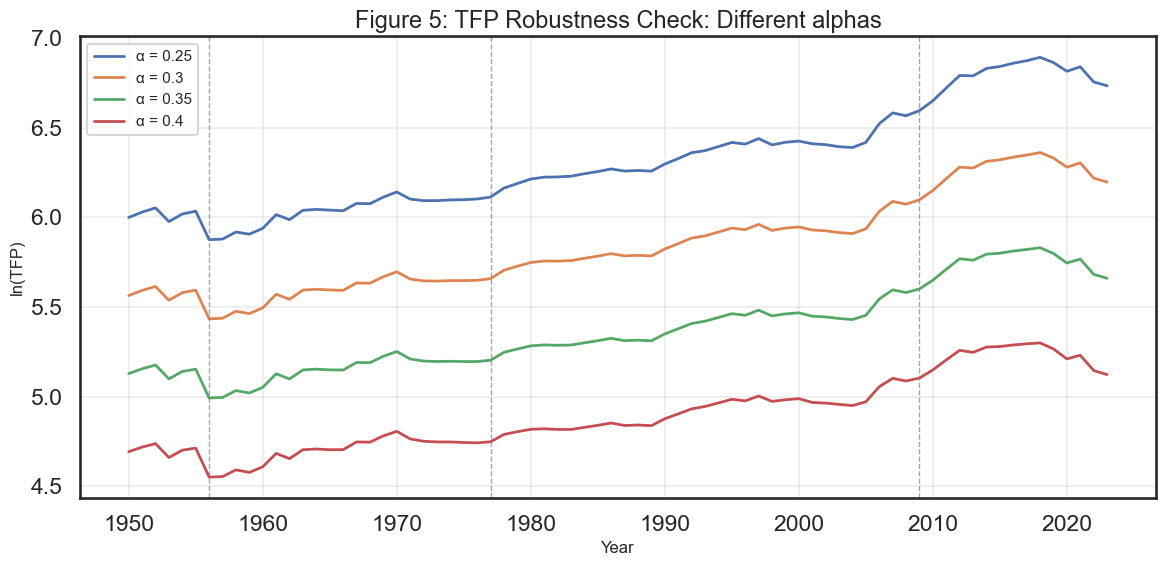

In [38]:
# Plot log TFP under each α value to visually confirm the trend shape is robust across assumptions
plt.figure(figsize=(12, 6))

for a in alphas:
    plt.plot(data_tfp['year'], data_tfp[f'ln_TFP_alpha_{a}'], 
             label=f'α = {a}', linewidth=2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('ln(TFP)', fontsize=12)
plt.title('Figure 5: TFP Robustness Check: Different alphas', fontsize=17)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Vertical lines at sub-period boundaries
for year in [1956, 1977, 2009]:
    plt.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    
plt.show()

Before we aggregate them into decades, we compute annual growth rates using log differences, $g_t = \ln(Y_t / Y_{t-1})$. 

Looking at the first five years tells us what's happening year-to-year, rather than decade-to-decade, and allows us to have a closer look at Sri Lanka's short-term growth patterns.

In [39]:
# Function to compute annual growth rates using log differences: g_t = ln(X_t / X_{t-1})
# Log growth rates approximate percentage changes and are additive over time
def compute_growth_rate(X):
    return np.log(X[1:] / X[:-1])

# Extract GDP in levels and compute its year-on-year growth rate
Y = data_tfp["Y"].values
dY = compute_growth_rate(Y)

# Years array for labelling output
year = data_tfp['year'].values

# Print the first five growth rates as a quick sanity check
print("Year-by-year GDP growth rate for first five years:\n")
print("Year \t\t ln(Y_t/Y_{t-1})")
for y1, y2, gy in zip(year[:5], year[1:6], dY[:5]):
    print(f"{y1:.0f}-{y2:.0f} \t\t {gy:.4f}")

Year-by-year GDP growth rate for first five years:

Year 		 ln(Y_t/Y_{t-1})
1950-1951 		 0.0656
1951-1952 		 0.0589
1952-1953 		 -0.0453
1953-1954 		 0.0728
1954-1955 		 0.0483


# C. Growth accounting

In Part C we perform growth accounting, decomposing Sri Lanka's GDP growth into contributions from capital, labour, (human capital), and TFP. We split the time period into four sub-periods based on key structural breaks in Sri Lanka's history: 1950–1956 (post-independence), 1956–1977 (nationalist economic policies), 1977–2009 (liberalisation and civil war), and 2009–2023 (post-war recovery and COVID crisis). More on the reasoning behind this choice can be read in our essay.

In [40]:
# Compute average annual GDP growth rate by decade using log differences: (1/n) * ln(Y_end / Y_start)
# This annualises growth over each period for comparability across decades of different lengths

# We defined our sub periods based on historical events in Sri Lanka:

periods = ['1950-1956', '1956-1977', '1977-2009', '2009-2023'] 
periods_years = [(1950, 1956), (1956, 1977), (1977, 2009), (2009, 2023)]

annualized_Y= []

for (start_year, end_year) in periods_years:
    start_data = data_tfp[data_tfp['year'] == start_year].iloc[0]
    end_data = data_tfp[data_tfp['year'] == end_year].iloc[0]
    n = end_year - start_year
    # Annualised log growth rate over the period
    y_growth = (1/n) * np.log(end_data['Y'] / start_data['Y'])
    annualized_Y.append(y_growth)

print("Average annual Y growth:")
for period, growth in zip(periods_years, annualized_Y):
    print(f"{period}: {growth:.4f}")

Average annual Y growth:
(1950, 1956): 0.0119
(1956, 1977): 0.0489
(1977, 2009): 0.0495
(2009, 2023): 0.0299


We also plot a visual graph to better capture each time period trends. 

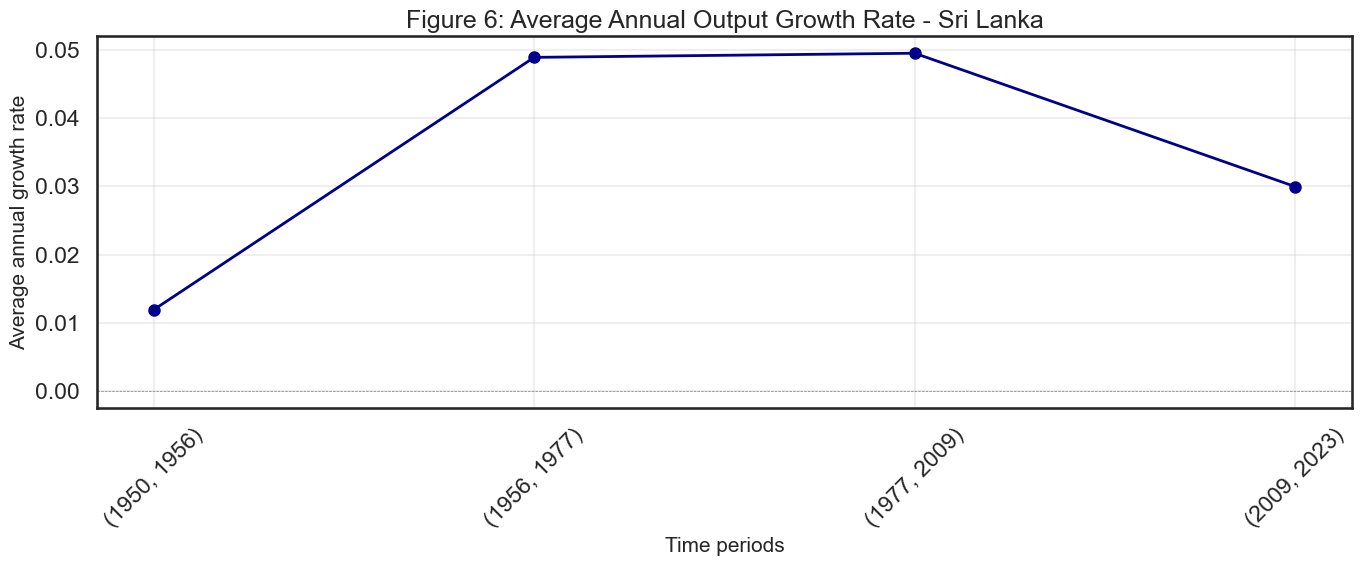

In [54]:
# Plot growth rates to identify structural shifts in Sri Lanka's growth trajectory
plt.figure(figsize=(14, 6))
x_pos = np.arange(len(periods_years))

plt.plot(x_pos, annualized_Y, marker='o', markersize=8, linewidth=2, color='darkblue')

plt.xlabel('Time periods', fontsize=15)
plt.ylabel('Average annual growth rate', fontsize=15)
plt.title('Figure 6: Average Annual Output Growth Rate - Sri Lanka', fontsize=18)
plt.xticks(x_pos, periods_years, rotation=45)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

Indeed, we can see a steep negative slope for 2009-2023.

## 1. Without human capital decompisition

We first decompose GDP growth using the traditional Solow model without human capital, where $Y = A \cdot K^{\alpha} \cdot L^{1-\alpha}$. Taking log differences, total output growth $g_Y$ can be expressed as:

$$g_Y = \alpha \cdot g_K + (1-\alpha) \cdot g_L + g_A$$

where $\alpha \cdot g_K$ is capital's contribution, $(1-\alpha) \cdot g_L$ is labour's contribution, and $g_A$ is the TFP residual. By construction, the three contributions sum to total GDP growth.

We start by accounting per year, then we aggregate per time period. 

In [55]:
# Compute TFP WITHOUT human capital: from Y = A · K^α · L^(1-α), we solve A = Y / (K^α · L^(1-α))
# This version excludes human capital to isolate its contribution later
alpha = 0.3

Y = data_tfp["Y"].values
K = data_tfp["K"].values
L = data_tfp["L"].values

A_no_hc = Y / (K**alpha * L**(1 - alpha))
data_tfp['TFP_no_hc'] = A_no_hc
data_tfp['ln_TFP_no_hc'] = np.log(A_no_hc)

print(data_tfp[['year', 'TFP', 'TFP_no_hc']].head())

# Growth accounting (without human capital)

# Initialise a dataframe to store annualised growth rates for each period
avg_growth_rates_no_hc = pd.DataFrame(
    data = np.full((4, 4), np.nan),
    columns = ['Y growth', 'K growth', 'L growth', 'A growth']
)

avg_growth_rates_no_hc['year'] = ["1950-1956", "1956-1977", "1977-2009", "2009-2023"]
avg_growth_rates_no_hc = avg_growth_rates_no_hc.set_index('year')

# Look up the row index for each boundary year to access data by position
idx_1950 = data_tfp[data_tfp['year'] == 1950].index[0]
idx_1956 = data_tfp[data_tfp['year'] == 1956].index[0]
idx_1977 = data_tfp[data_tfp['year'] == 1977].index[0]
idx_2009 = data_tfp[data_tfp['year'] == 2009].index[0]
idx_2023 = data_tfp[data_tfp['year'] == 2023].index[0]

# Define each period with its start/end indices and length
periods_data = [
    ('1950-1956', idx_1950, idx_1956, 6),
    ('1956-1977', idx_1956, idx_1977, 21),
    ('1977-2009', idx_1977, idx_2009, 32),
    ('2009-2023', idx_2009, idx_2023, 14)
]

# Compute annualised log growth rates: g = (1/n) * ln(X_end / X_start) for each factor
for period, idx_start, idx_end, n_years in periods_data:
    avg_growth_rates_no_hc.loc[period, 'Y growth'] = (1/n_years) * np.log(data_tfp.loc[idx_end, 'Y'] / data_tfp.loc[idx_start, 'Y'])
    avg_growth_rates_no_hc.loc[period, 'K growth'] = (1/n_years) * np.log(data_tfp.loc[idx_end, 'K'] / data_tfp.loc[idx_start, 'K'])
    avg_growth_rates_no_hc.loc[period, 'L growth'] = (1/n_years) * np.log(data_tfp.loc[idx_end, 'L'] / data_tfp.loc[idx_start, 'L'])
    avg_growth_rates_no_hc.loc[period, 'A growth'] = (1/n_years) * np.log(data_tfp.loc[idx_end, 'TFP_no_hc'] / data_tfp.loc[idx_start, 'TFP_no_hc'])

# Convert growth rates into shares of GDP growth to see each factor's contribution
# eg K contribution = α * (K growth / Y growth), A contribution is the residual share
df_contribs_no_hc = avg_growth_rates_no_hc.copy()
df_contribs_no_hc['K contribution'] = alpha * (df_contribs_no_hc['K growth'] / df_contribs_no_hc['Y growth'])
df_contribs_no_hc['L contribution'] = (1 - alpha) * (df_contribs_no_hc['L growth'] / df_contribs_no_hc['Y growth'])
df_contribs_no_hc['A contribution'] = df_contribs_no_hc['A growth'] / df_contribs_no_hc['Y growth']

df_contribs_no_hc = df_contribs_no_hc[['Y growth', 'K contribution', 'L contribution', 'A contribution']]

print("\n" + "=" * 80)
print("Growth Accounting - WITHOUT Human Capital")
print("=" * 80)
print(df_contribs_no_hc)

# Sanity check: K + L + A contributions should sum to 1 by construction
df_contribs_no_hc['Total'] = df_contribs_no_hc[['K contribution', 'L contribution', 'A contribution']].sum(axis=1)
print("\nVerification (should sum to 1):")
print(df_contribs_no_hc[['K contribution', 'L contribution', 'A contribution', 'Total']])

   year         TFP   TFP_no_hc
0  1950  260.853339  343.817596
1  1951  268.392063  355.315964
2  1952  274.404615  364.879793
3  1953  254.126489  339.407693
4  1954  264.986663  355.475047

Growth Accounting - WITHOUT Human Capital
           Y growth  K contribution  L contribution  A contribution
year                                                               
1950-1956  0.011916        1.190139        1.241809       -1.431948
1956-1977  0.048874        0.290215        0.289905        0.419879
1977-2009  0.049479        0.328484        0.247443        0.424073
2009-2023  0.029947        0.628336        0.111502        0.260162

Verification (should sum to 1):
           K contribution  L contribution  A contribution  Total
year                                                            
1950-1956        1.190139        1.241809       -1.431948    1.0
1956-1977        0.290215        0.289905        0.419879    1.0
1977-2009        0.328484        0.247443        0.424073    1.0

We've verified, from the table above, that the contributions sum to 1 for each decade. 

We now plot the % point contributions in log points to see the actual magnitude of each factor's contribution to GDP growth per time period, instead of their relative shares.

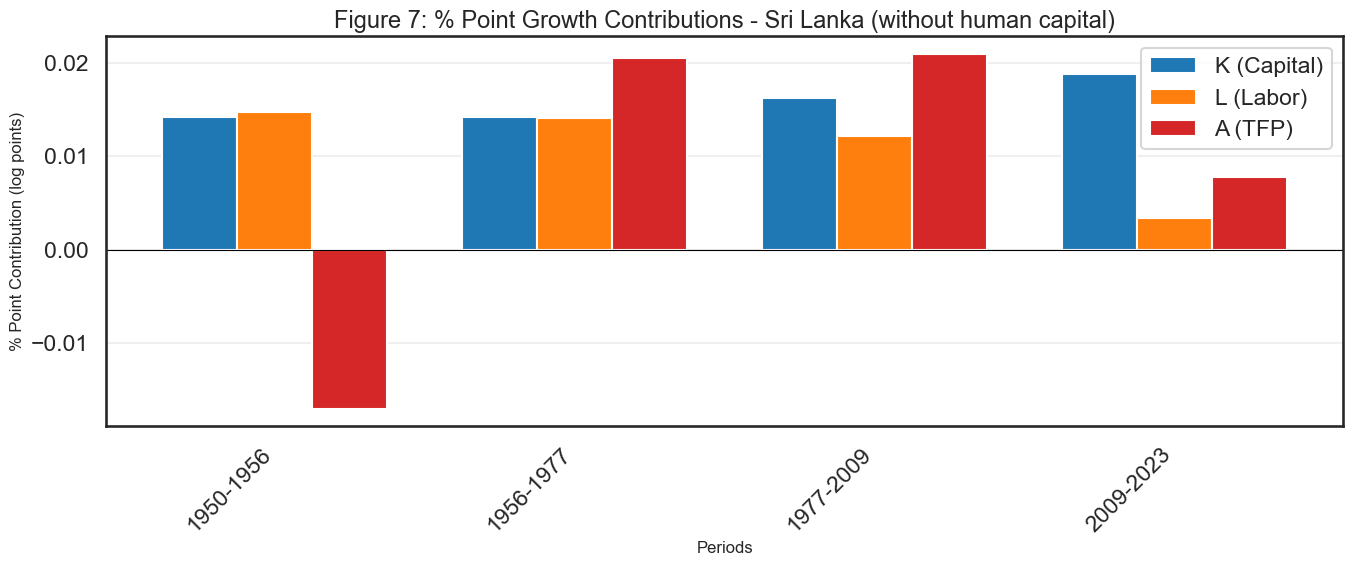

In [67]:
# Compute % poiny contributions: how many log points each factor adds to annual GDP growth 
# K contribution = α * gK, L contribution = (1-α) * gL, A contribution = gA (the residual)
periods = avg_growth_rates_no_hc.index.tolist()

K_contrib_abs = [alpha * avg_growth_rates_no_hc.loc[p, 'K growth'] for p in periods]
L_contrib_abs = [(1 - alpha) * avg_growth_rates_no_hc.loc[p, 'L growth'] for p in periods]
A_contrib_abs = [avg_growth_rates_no_hc.loc[p, 'A growth'] for p in periods]

# Grouped bar chart to compare the magnitude of each factor's contribution across periods
plt.figure(figsize=(14, 6))
x_pos = np.arange(len(periods))
width = 0.25

plt.bar(x_pos - width, K_contrib_abs, width, label='K (Capital)', color='#1f77b4')
plt.bar(x_pos, L_contrib_abs, width, label='L (Labor)', color='#ff7f0e')
plt.bar(x_pos + width, A_contrib_abs, width, label='A (TFP)', color='#d62728')

plt.xlabel('Periods', fontsize=12)
plt.ylabel('% Point Contribution (log points)', fontsize=12)
plt.title('Figure 7: % Point Growth Contributions - Sri Lanka (without human capital)', fontsize=17)
plt.xticks(x_pos, periods, rotation=45, ha='right')
plt.legend(loc='upper right')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

We also plotted the % contribution to growth, which express each factor as a proportion of total GDP growth (summing to 1). This complements the absolute chart by showing the relative importance of capital, labour, and TFP for each time period, regardless of whether overall growth was high or low.

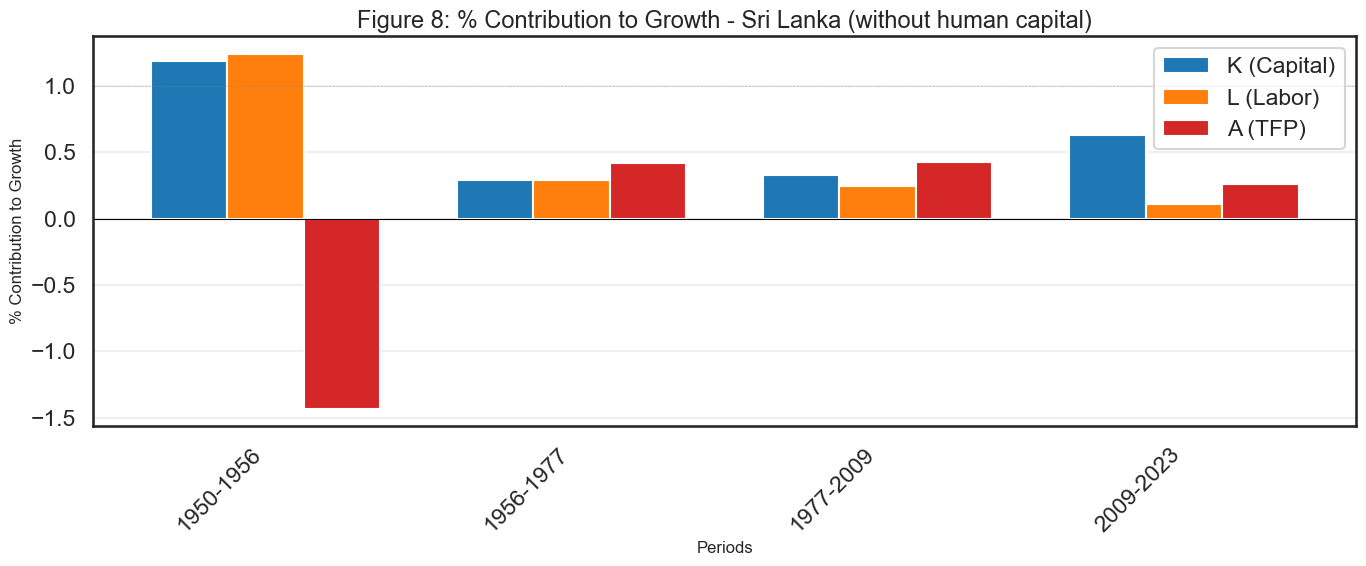

In [78]:
# Compute each factor's share of total GDP growth (contributions should sum to 1 each period)
# This shows the relative importance of K, L, and TFP rather than their absolute magnitudes
periods = avg_growth_rates_no_hc.index.tolist()

K_contrib_share = [alpha * avg_growth_rates_no_hc.loc[p, 'K growth'] / avg_growth_rates_no_hc.loc[p, 'Y growth'] for p in periods]
L_contrib_share = [(1 - alpha) * avg_growth_rates_no_hc.loc[p, 'L growth'] / avg_growth_rates_no_hc.loc[p, 'Y growth'] for p in periods]
A_contrib_share = [avg_growth_rates_no_hc.loc[p, 'A growth'] / avg_growth_rates_no_hc.loc[p, 'Y growth'] for p in periods]

# Grouped bar chart comparing the proportion of growth explained by each factor
plt.figure(figsize=(14, 6))
x_pos = np.arange(len(periods))
width = 0.25

plt.bar(x_pos - width, K_contrib_share, width, label='K (Capital)', color='#1f77b4')
plt.bar(x_pos, L_contrib_share, width, label='L (Labor)', color='#ff7f0e')
plt.bar(x_pos + width, A_contrib_share, width, label='A (TFP)', color='#d62728')

plt.xlabel('Periods', fontsize=12)
plt.ylabel('% Contribution to Growth', fontsize=12)
plt.title('Figure 8: % Contribution to Growth - Sri Lanka (without human capital)', fontsize=17)
plt.xticks(x_pos, periods, rotation=45, ha='right')
plt.legend(loc='upper right')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)  # Reference line: shares should sum to 1
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 2. With human capital decompisition

Now, we add extend our growth accounting framework by incorporating human capital ($h$) into the production function: $Y = K^{\alpha}(AhL)^{1-\alpha}$. This separates workforce quality from raw TFP, giving us four sources of growth:

$$g_Y = \alpha \cdot g_K + (1-\alpha) \cdot g_L + (1-\alpha) \cdot g_h + g_A$$

where the labour term is now split into employment growth ($g_L$) and human capital growth ($g_h$), both weighted by $(1-\alpha)$. We expect the TFP residual ($g_A$) to be smaller, as the portion previously attributed to productivity that was actually due to improvements in workforce quality should be captured by $g_h$.

Other than including human capital, everything else is the same. We expect all the factors to sum to 1.  

In [79]:
# Compute TFP WITH human capital: Y = A · K^α · (hL)^(1-α), so A = Y / (K^α · (hL)^(1-α))
# Including h separates workforce quality from raw TFP, giving a cleaner productivity measure
A = Y / (K**alpha * (h * L)**(1 - alpha))
data_tfp['TFP'] = A
data_tfp['ln_TFP'] = np.log(A)

print(data_tfp[['year', 'TFP', 'h']].head())

# Growth accounting (with human capital)

# Initialise dataframe — now with 5 columns to include human capital growth
avg_growth_rates = pd.DataFrame(
    data=np.full((4, 5), np.nan),
    columns=['Y growth', 'K growth', 'L growth', 'h growth', 'A growth']
)

avg_growth_rates['year'] = ["1950-1956", "1956-1977", "1977-2009", "2009-2023"]
avg_growth_rates = avg_growth_rates.set_index('year')

# Look up row indices for each boundary year
idx = {yr: data_tfp[data_tfp['year'] == yr].index[0] 
       for yr in [1950, 1956, 1977, 2009, 2023]}

# Define periods with start/end years and period length
periods_data = [
    ('1950-1956', 1950, 1956, 6), ('1956-1977', 1956, 1977, 21),
    ('1977-2009', 1977, 2009, 32), ('2009-2023', 2009, 2023, 14)
]

# Compute annualised log growth rates for each factor including human capital
for period, y_start, y_end, n in periods_data:
    for var, col in [('Y', 'Y growth'), ('K', 'K growth'), ('L', 'L growth'), 
                     ('h', 'h growth'), ('TFP', 'A growth')]:
        avg_growth_rates.loc[period, col] = (1/n) * np.log(
            data_tfp.loc[idx[y_end], var] / data_tfp.loc[idx[y_start], var])

# Convert growth rates into shares of GDP growth
# h contribution is weighted by (1-α) since human capital enters through the labour term
df_contribs_long = avg_growth_rates.copy()
df_contribs_long['K contribution'] = alpha * (df_contribs_long['K growth'] / df_contribs_long['Y growth'])
df_contribs_long['L contribution'] = (1 - alpha) * (df_contribs_long['L growth'] / df_contribs_long['Y growth'])
df_contribs_long['h contribution'] = (1 - alpha) * (df_contribs_long['h growth'] / df_contribs_long['Y growth'])
df_contribs_long['A contribution'] = df_contribs_long['A growth'] / df_contribs_long['Y growth']

df_contribs_long = df_contribs_long[['Y growth', 'K contribution', 'L contribution', 'h contribution', 'A contribution']]

print("\n" + "=" * 80)
print("Growth Accounting - WITH Human Capital")
print("=" * 80)
print(df_contribs_long)

# Sanity check: K + L + h + A contributions should sum to 1 by construction
df_contribs_long['Total'] = (df_contribs_long['K contribution'] + 
                              df_contribs_long['L contribution'] + 
                              df_contribs_long['h contribution'] + 
                              df_contribs_long['A contribution'])
print("\nVerification (should sum to 1):")
df_contribs_long[['K contribution', 'L contribution', 'h contribution', 'A contribution', 'Total']]

   year         TFP         h
0  1950  260.853339  1.483648
1  1951  268.392063  1.493016
2  1952  274.404615  1.502442
3  1953  254.126489  1.511928
4  1954  264.986663  1.521474

Growth Accounting - WITH Human Capital
           Y growth  K contribution  L contribution  h contribution  \
year                                                                  
1950-1956  0.011916        1.190139        1.241809        0.383519   
1956-1977  0.048874        0.290215        0.289905        0.201557   
1977-2009  0.049479        0.328484        0.247443        0.146438   
2009-2023  0.029947        0.628336        0.111502        0.024048   

           A contribution  
year                       
1950-1956       -1.815468  
1956-1977        0.218323  
1977-2009        0.277635  
2009-2023        0.236114  

Verification (should sum to 1):


,K contribution,L contribution,h contribution,A contribution,Total
year,,,,,
1950-1956,1.190139,1.241809,0.383519,-1.815468,1.0
1956-1977,0.290215,0.289905,0.201557,0.218323,1.0
1977-2009,0.328484,0.247443,0.146438,0.277635,1.0
2009-2023,0.628336,0.111502,0.024048,0.236114,1.0


Indeed again, K + L + h + A sum to 1. 

Again, we plot the absolute contributions in log points, now with four bars to include human capital. Comparing this to the earlier chart without human capital, we can see how much of what was previously attributed to TFP is now explained by improvements in workforce quality (h).

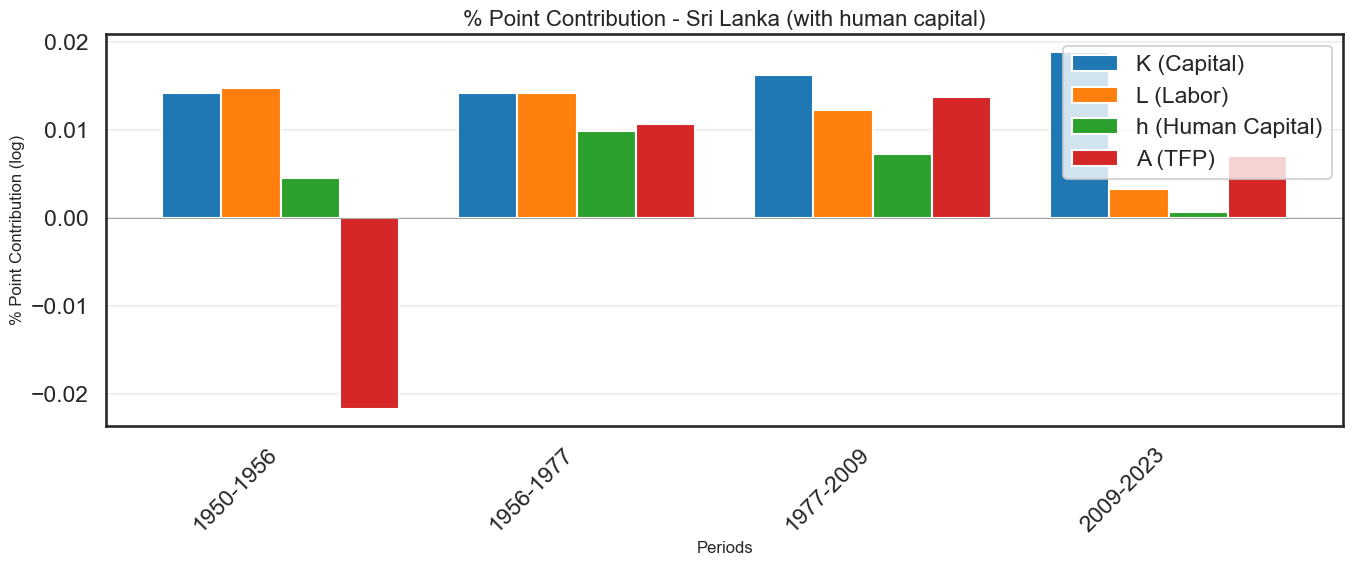

In [ ]:
# Compute % point contributions in log points: how much each factor adds to total GDP growth per period
# eg α * gK gives capital's absolute contribution, while TFP is the residual
periods = avg_growth_rates.index.tolist()

K_contrib_abs = [alpha * avg_growth_rates.loc[p, 'K growth'] for p in periods]
L_contrib_abs = [(1 - alpha) * avg_growth_rates.loc[p, 'L growth'] for p in periods]
h_contrib_abs = [(1 - alpha) * avg_growth_rates.loc[p, 'h growth'] for p in periods]
A_contrib_abs = [avg_growth_rates.loc[p, 'A growth'] for p in periods]

# Grouped bar chart with 4 bars per period to compare magnitudes across factors
plt.figure(figsize=(14, 6))
x_pos = np.arange(len(periods))
width = 0.2

plt.bar(x_pos - 1.5*width, K_contrib_abs, width, label='K (Capital)', color='#1f77b4')
plt.bar(x_pos - 0.5*width, L_contrib_abs, width, label='L (Labor)', color='#ff7f0e')
plt.bar(x_pos + 0.5*width, h_contrib_abs, width, label='h (Human Capital)', color='#2ca02c')
plt.bar(x_pos + 1.5*width, A_contrib_abs, width, label='A (TFP)', color='#d62728')

plt.xlabel('Periods', fontsize=12)
plt.ylabel('% Point Contribution (log)', fontsize=12)
plt.title('Figure 9: % Point Contribution for Sri Lanka (with human capital)', fontsize=16)
plt.xticks(x_pos, periods, rotation=45, ha='right')
plt.legend(loc='upper right')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Similarly, we plotted the % contribution to growth including human capital. This shows the relative importance of each factor per time period. 

Now, human capital absorbs part of what the TFP residual captured in the model without h. 

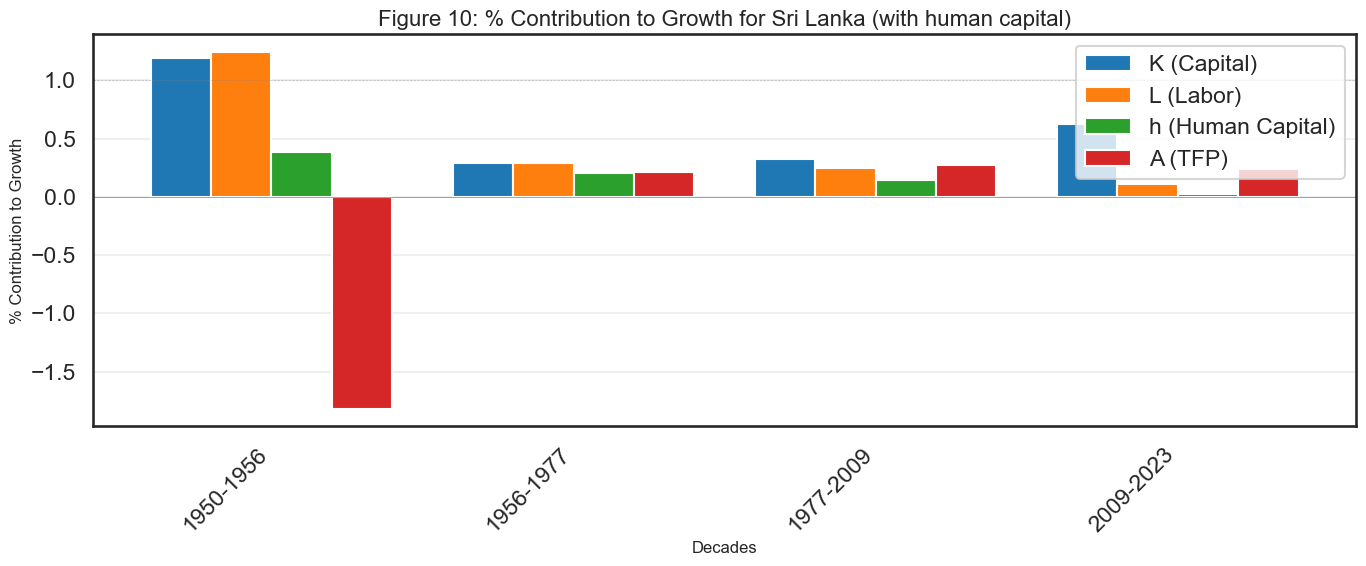

In [88]:
# Compute % contribution to growth: each factor's growth as a proportion of total GDP growth
# Shares sum to 1 by construction, showing the relative importance of each driver
periods_decade = avg_growth_rates.index.tolist()

K_contrib_share = [alpha * avg_growth_rates.loc[p, 'K growth'] / avg_growth_rates.loc[p, 'Y growth'] for p in periods_decade]
L_contrib_share = [(1 - alpha) * avg_growth_rates.loc[p, 'L growth'] / avg_growth_rates.loc[p, 'Y growth'] for p in periods_decade]
h_contrib_share = [(1 - alpha) * avg_growth_rates.loc[p, 'h growth'] / avg_growth_rates.loc[p, 'Y growth'] for p in periods_decade]
A_contrib_share = [avg_growth_rates.loc[p, 'A growth'] / avg_growth_rates.loc[p, 'Y growth'] for p in periods_decade]

# Grouped bar chart showing what fraction of each decade's growth is explained by each factor
plt.figure(figsize=(14, 6))
x_pos = np.arange(len(periods_decade))
width = 0.2

plt.bar(x_pos - 1.5*width, K_contrib_share, width, label='K (Capital)', color='#1f77b4')
plt.bar(x_pos - 0.5*width, L_contrib_share, width, label='L (Labor)', color='#ff7f0e')
plt.bar(x_pos + 0.5*width, h_contrib_share, width, label='h (Human Capital)', color='#2ca02c')
plt.bar(x_pos + 1.5*width, A_contrib_share, width, label='A (TFP)', color='#d62728')

plt.xlabel('Decades', fontsize=12)
plt.ylabel('% Contribution to Growth', fontsize=12)
plt.title('Figure 10: % Contribution to Growth for Sri Lanka (with human capital)', fontsize=16)
plt.xticks(x_pos, periods_decade, rotation=45, ha='right')
plt.legend(loc='upper right')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)  # Reference: shares should sum to 1
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

We are done with growth accounting!!

# D. Labour productivity

In our final part D, we compute labour productivity in both levels and logs for our trend analysis. 

Labour producitvity is captured by GDP per worker. 

In [89]:
# Compute labour productivity (Y/L = output per worker) and its log for trend analysis
data_tfp['labour_prod'] = data_tfp['Y'] / data_tfp['L']
data_tfp['ln_labour_prod'] = np.log(data_tfp['labour_prod'])

# Keep labour productivity alongside human capital for later decomposition
df_labour_prod = data_tfp[['year', 'labour_prod', 'ln_labour_prod', 'h']].copy()

print("Labour productivity series (GDP per worker) for the first five years")
print(df_labour_prod.head())

Labour productivity series (GDP per worker) for the first five years
   year  labour_prod  ln_labour_prod         h
0  1950  5272.910847        8.570338  1.483648
1  1951  5506.844580        8.613747  1.493016
2  1952  5710.191707        8.650008  1.502442
3  1953  5333.603721        8.581782  1.511928
4  1954  5613.439520        8.632919  1.521474


Finally, we plot both Sri Lanka's levels (left) and log levels (right) side by side to better visualise. 

The levels plot shows the absolute scale of output per worker over time, while the log plot reveals whether productivity growth has been constant (a straight line) or accelerating.

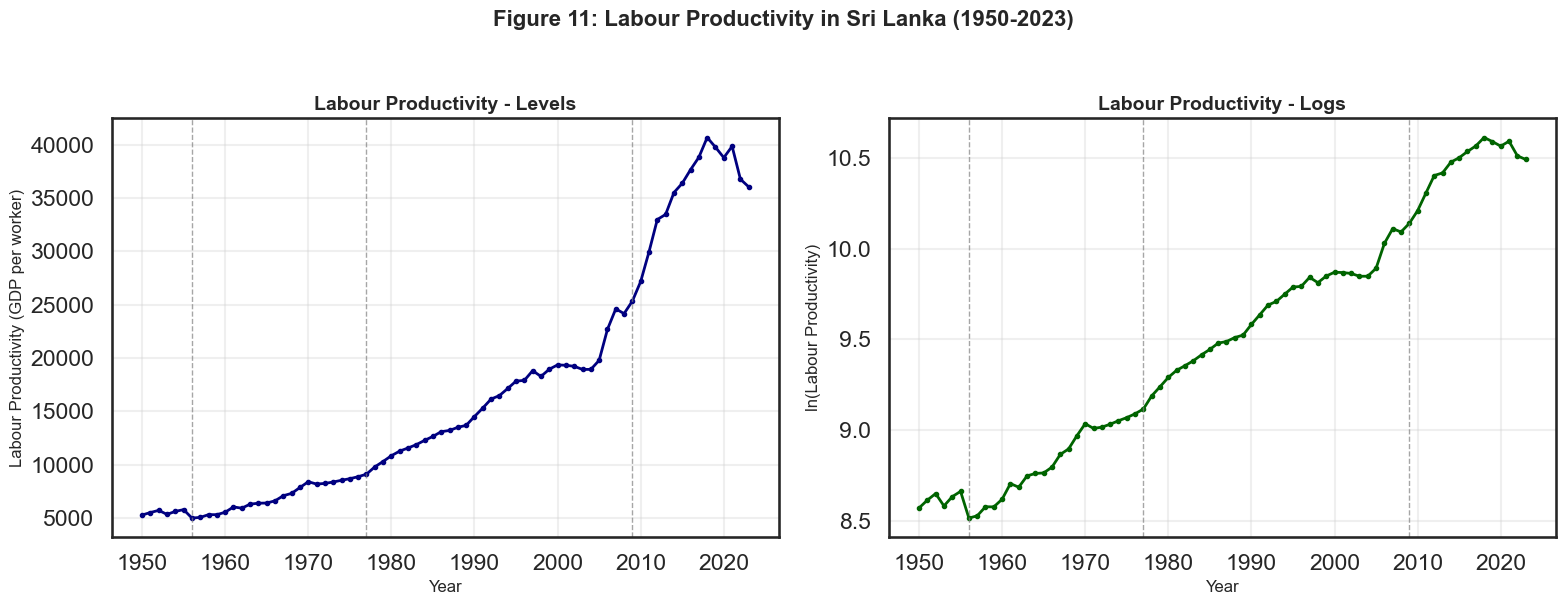

In [95]:
# Side-by-side plots of labour productivity in levels and logs to examine the growth pattern
# Logs help reveal whether productivity growth has been constant (linear in logs) or accelerating
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: labour productivity in levels: shows the absolute scale of growth
axes[0].plot(df_labour_prod['year'], df_labour_prod['labour_prod'], 
             linewidth=2, color='navy', marker='o', markersize=3)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Labour Productivity (GDP per worker)', fontsize=12)
axes[0].set_title('Labour Productivity - Levels', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Right panel: log labour productivity: a straight line here would imply constant growth rates
axes[1].plot(df_labour_prod['year'], df_labour_prod['ln_labour_prod'], 
             linewidth=2, color='darkgreen', marker='o', markersize=3)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('ln(Labour Productivity)', fontsize=12)
axes[1].set_title('Labour Productivity - Logs', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 11: Labour Productivity in Sri Lanka (1950-2023)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Add vertical lines to both panels
for year in [1956, 1977, 2009]:
    axes[0].axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    axes[1].axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    
plt.show()

## Explore Sri Lanka's economic trends by exploring other variables

To better understand Sri Lanka's economy and its underlying trends, we decided to extract and plot additional variables representing age of schooling and employment. 

For this, we loaded additional variables of `emp` for employment rate, and `hc` (human capital index), based on years of schooling and returns to education. 

In [96]:
# Load additional variables from PWT and filter for Sri Lanka. We also restrict our analysis period to 1950-2023 as always. 
data_labour = pd.read_excel('pwt110_download_2025_11_24.xlsx', sheet_name='Data')

data_labour = data_labour.loc[data_labour["country"] == "Sri Lanka", 
                               ["year", "hc", "emp", "pop"]]
data_labour = data_labour.reset_index(drop=True)

data_labour = data_labour[(data_labour["year"] >= 1950) & (data_labour["year"] <= 2023)]

# Compute employment rate as share of total population
data_labour["emp_rate"] = data_labour["emp"] / data_labour["pop"]

# We extract, hc, PWT's human capital index, based on years of schooling and returns to education
print(data_labour[["year", "hc", "emp", "emp_rate"]].head(10))

   year        hc       emp  emp_rate
0  1950  1.483648  2.499192  0.340715
1  1951  1.493016  2.555272  0.338390
2  1952  1.502442  2.613895  0.336064
3  1953  1.511928  2.674440  0.333739
4  1954  1.521474  2.732963  0.331413
5  1955  1.531080  2.785821  0.329087
6  1956  1.542920  2.837167  0.326762
7  1957  1.554853  2.890802  0.324435
8  1958  1.566877  2.944427  0.322110
9  1959  1.578995  3.001579  0.319784


Then we plot these graphs overtime, because visualisations better capture the trends. 

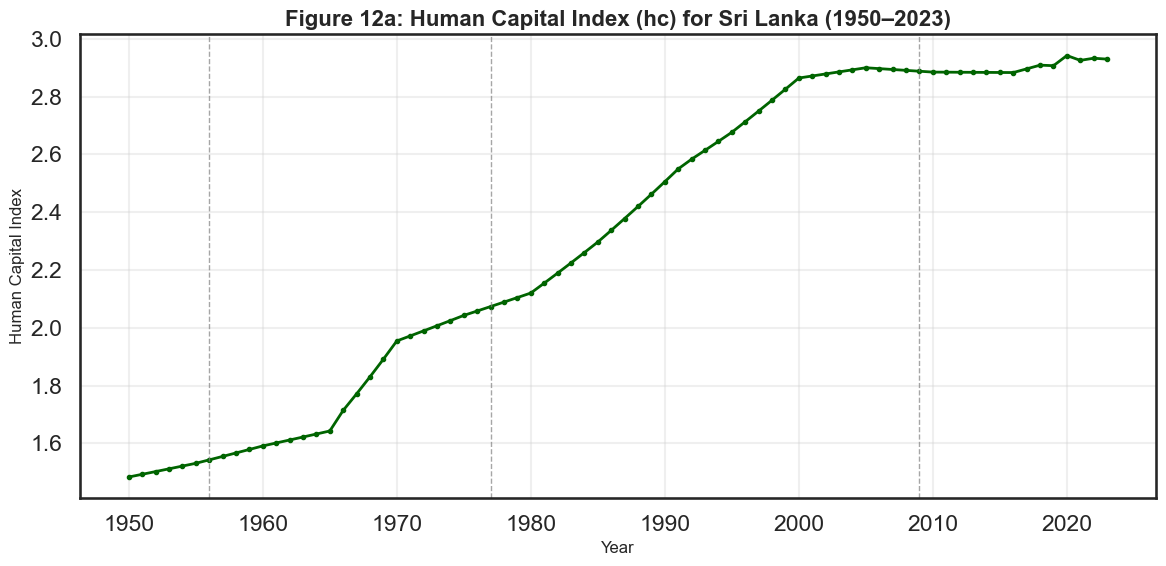

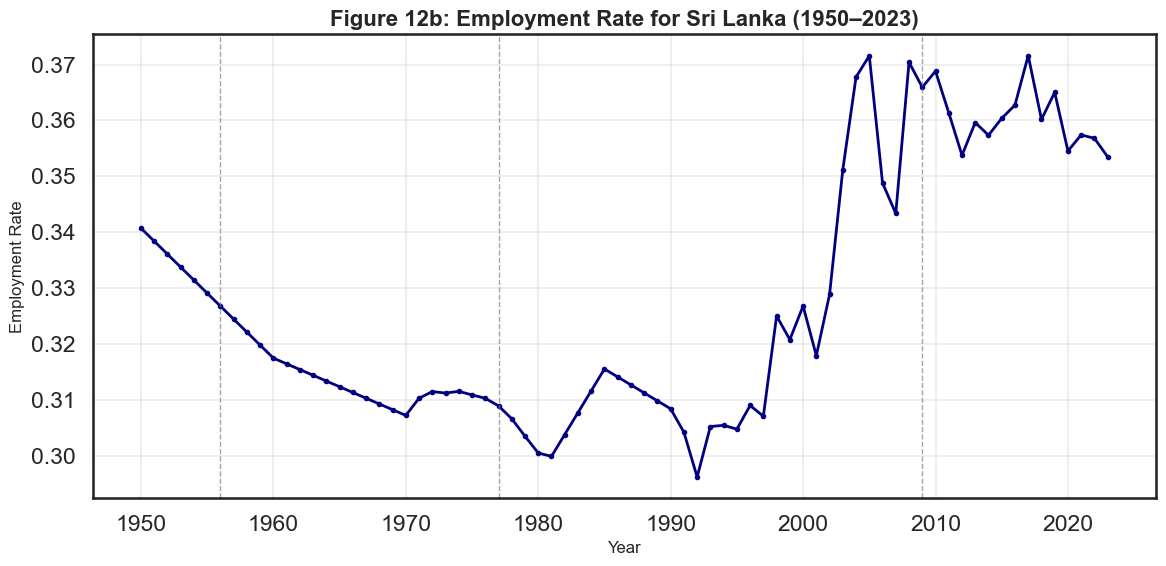

In [103]:
# Plotting human capital index over time, which should capture improvements in workforce quality
plt.figure(figsize=(12, 6))
plt.plot(data_labour['year'], data_labour['hc'], 
         linewidth=2, color='darkgreen', marker='o', markersize=3)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Human Capital Index', fontsize=12)
plt.title('Figure 12a: Human Capital Index (hc) for Sri Lanka (1950–2023)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Vertical lines at sub-period boundaries
for year in [1956, 1977, 2009]:
    plt.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.show()

# Plotting employment rate over time, which shows labour market participation trends
plt.figure(figsize=(12, 6))
plt.plot(data_labour['year'], data_labour['emp_rate'], 
         linewidth=2, color='navy', marker='o', markersize=3)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Employment Rate', fontsize=12)
plt.title('Figure 12b: Employment Rate for Sri Lanka (1950–2023)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Vertical lines at sub-period boundaries
for year in [1956, 1977, 2009]:
    plt.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.show()

Further, we noticed very similar patterns between log TFP and log labour productivity from the earlier graphs. To confirm our hypotheses, we plotted log labour productivity and log TFP on the same graph. 

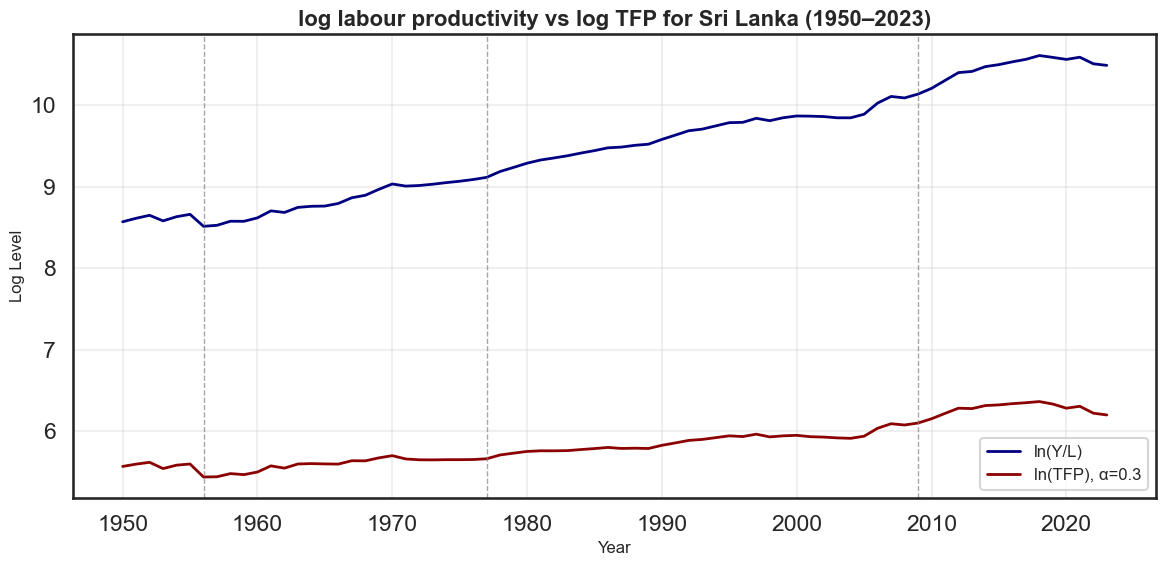

In [ ]:
# Plot log labour productivity and log TFP (α=0.3) together to compare productivity trends
plt.figure(figsize=(12, 6))

plt.plot(df_labour_prod['year'], df_labour_prod['ln_labour_prod'], 
         linewidth=2, color='navy', label='ln(Y/L)')

plt.plot(data_tfp['year'], data_tfp['ln_TFP'], 
         linewidth=2, color='darkred', label='ln(TFP), α=0.3')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Log Level', fontsize=12)
plt.title('Figure 13: log labour productivity vs log TFP for Sri Lanka (1950–2023)', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Vertical lines at sub-period boundaries
for year in [1956, 1977, 2009]:
    plt.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.show()

We also plotted capital deepening graph, to support our analysis of the Solow model.

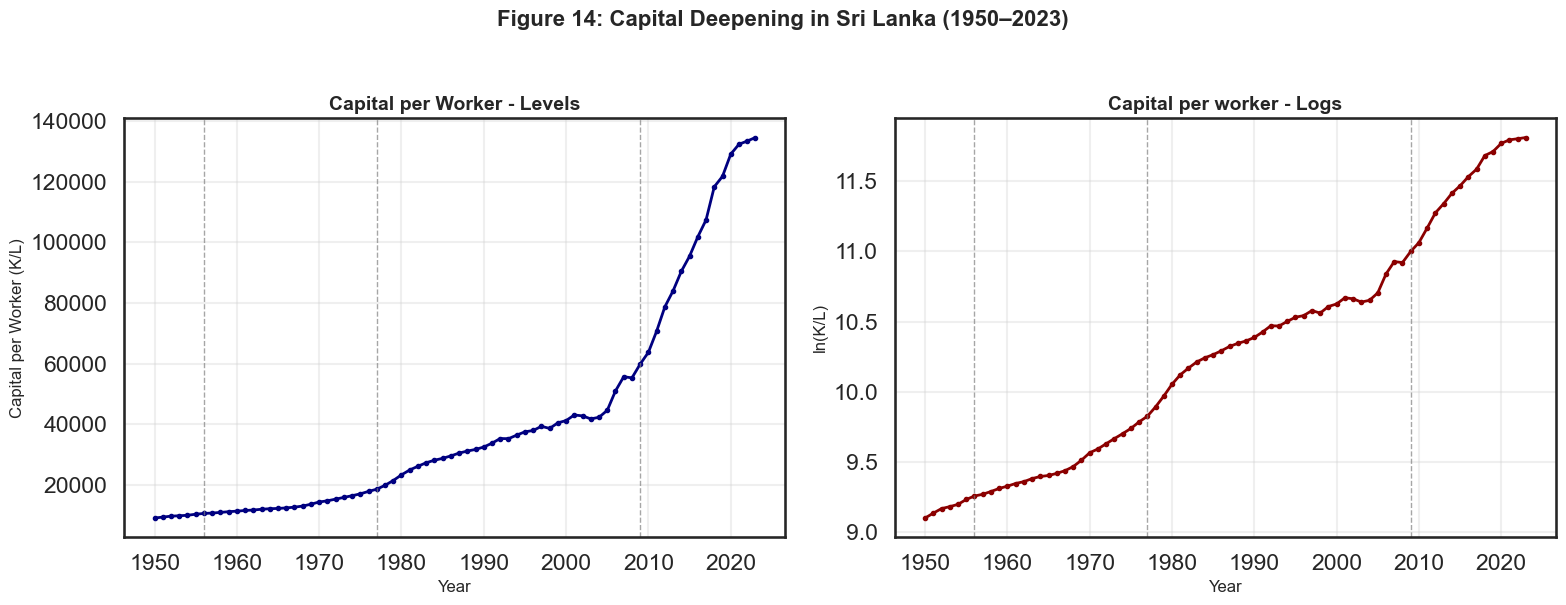

In [106]:
# Plot capital per worker (K/L) overtime to examine capital deepening
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Compute capital per worker (levels and logs)
data_tfp['K_per_L'] = data_tfp['K'] / data_tfp['L']
data_tfp['ln_K_per_L'] = np.log(data_tfp['K_per_L'])

# Left: Plotting capital per worker in levels
axes[0].plot(data_tfp['year'], data_tfp['K_per_L'], 
             linewidth=2, color='navy', marker='o', markersize=3)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Capital per Worker (K/L)', fontsize=12)
axes[0].set_title('Capital per Worker - Levels', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
for year in [1956, 1977, 2009]:
    axes[0].axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Right: Plotting log capital per worker
axes[1].plot(data_tfp['year'], data_tfp['ln_K_per_L'], 
             linewidth=2, color='darkred', marker='o', markersize=3)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('ln(K/L)', fontsize=12)
axes[1].set_title('Capital per worker - Logs', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
for year in [1956, 1977, 2009]:
    axes[1].axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.suptitle('Figure 14: Capital Deepening in Sri Lanka (1950–2023)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()